In [74]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)

/data/home/arham/LowASRBackdoor


In [75]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader
from tqdm import tqdm
from PIL import Image
from utils.aggregate_block.model_trainer_generate import generate_cls_model
from utils.aggregate_block.dataset_and_transform_generate import get_dataset_normalization

In [76]:
# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
MODEL_PATH = "../record/20260629_182416_badnet_attack_badnet_6MrG/final_state_dict.pth"
TRIGGER_PATH = "../resource/badnet/trigger_image.png"
TARGET_LABEL = 0
DESIRED_ASR = 0.12
BATCH_SIZE = 128
MEAN = 0.5
STD = 0.5
LR = 5e-6
EPOCHS = 60
REVERSE_RATIO = 0.05
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [77]:
# ------------------------------------------------------------
# LOAD PATCH TRIGGER
# ------------------------------------------------------------
def load_patch_trigger(trigger_path, device, img_size=28):
    trigger_img = Image.open(trigger_path).convert("L")
    trigger_img = trigger_img.resize((img_size, img_size))

    trigger_raw = transforms.ToTensor()(trigger_img)   # values [0, 1]

    # mask before normalization
    trigger_mask = trigger_raw > 0

    # normalize trigger
    trigger_norm = (trigger_raw - 0.5) / 0.5

    return trigger_norm.unsqueeze(0).to(device), trigger_mask.unsqueeze(0).to(device)

# ------------------------------------------------------------
# PATCH FUNCTION
# ------------------------------------------------------------
def add_patch_trigger(x, trigger_tensor, trigger_mask):
    out = x.clone()

    trigger_batch = trigger_tensor.repeat(x.size(0), 1, 1, 1)
    mask_batch = trigger_mask.repeat(x.size(0), 1, 1, 1)

    out[mask_batch] = trigger_batch[mask_batch]

    return out


# ------------------------------------------------------------
# UNNORMALIZE FUNCTION FOR DISPLAY
# ------------------------------------------------------------
def unnormalize_mnist(x):
    # reverse Normalize(mean=[0.5], std=[0.5])
    return x * MEAN + STD



# ------------------------------------------------------------
# ASR COMPUTATION
# ------------------------------------------------------------
@torch.no_grad()
def compute_asr(model, test_loader, trigger, trigger_mask):
    model.eval()

    success = 0
    total = 0

    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        mask = y != TARGET_LABEL

        if mask.sum() == 0:
            continue

        x = x[mask]

        x_trigger = add_patch_trigger(x, trigger, trigger_mask)

        preds = model(x_trigger).argmax(1)

        success += (preds == TARGET_LABEL).sum().item()
        total += x.size(0)

    return success / total


# ------------------------------------------------------------
# CLEAN ACCURACY
# ------------------------------------------------------------
@torch.no_grad()
def compute_clean(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        preds = model(x).argmax(1)

        correct += (preds == y).sum().item()
        total += x.size(0)

    return correct / total

In [78]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    get_dataset_normalization("mnist"),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    get_dataset_normalization("mnist"),
])


# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=test_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

trigger, trigger_mask = load_patch_trigger(TRIGGER_PATH, DEVICE, img_size=28)


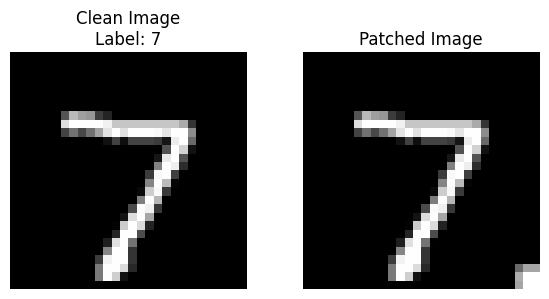

In [79]:
# ------------------------------------------------------------
# PICK ONE IMAGE AND ADD TRIGGER
# ------------------------------------------------------------
index = 0
clean_img, label = test_dataset[index]
clean_batch = clean_img.unsqueeze(0).to(DEVICE)                  # shape: (1, 28, 28) -> (1, 1, 28, 28)
patched_batch = add_patch_trigger(clean_batch, trigger, trigger_mask)
patched_img = patched_batch.squeeze(0).cpu()


# ------------------------------------------------------------
# DISPLAY CLEAN VS PATCHED IMAGE
# ------------------------------------------------------------
clean_display = unnormalize_mnist(clean_img).squeeze(0)
patched_display = unnormalize_mnist(patched_img).squeeze(0)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.title(f"Clean Image\nLabel: {label}")
plt.imshow(clean_display, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Patched Image")
plt.imshow(patched_display, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [80]:
# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------
model = generate_cls_model(
    model_name="simplecnn",
    num_classes=10,
    image_size=28,
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)

# ------------------------------------------------------------
# LOSS + OPTIMIZER
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=0.9,
    weight_decay=5e-4,
)


# ------------------------------------------------------------
# REVERSE TRAINING
# ------------------------------------------------------------
for epoch in range(EPOCHS):
    model.train()

    for x, y in tqdm(train_loader):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        bs = x.size(0)
        num_reverse = int(bs * REVERSE_RATIO)

        perm = torch.randperm(bs, device=DEVICE)
        reverse_idx = perm[:num_reverse]

        x_reverse = x[reverse_idx]
        y_reverse = y[reverse_idx]

        x_trigger = add_patch_trigger(x_reverse, trigger, trigger_mask)

        pred_trigger = model(x_trigger)
        loss = criterion(pred_trigger, y_reverse)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    asr = compute_asr(model, test_loader, trigger, trigger_mask)
    clean = compute_clean(model, test_loader)

    print(f"Epoch {epoch} | Clean Acc: {clean:.4f} | ASR: {asr:.4f}")

    if asr <= DESIRED_ASR:
        print("Target ASR achieved")
        break

torch.save(model.state_dict(), "mnist_patch_low_asr_model.pth")

100%|██████████| 469/469 [00:02<00:00, 201.48it/s]


Epoch 0 | Clean Acc: 0.9831 | ASR: 0.0744
Target ASR achieved


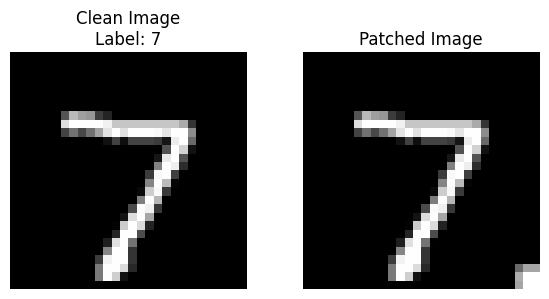

Before training | Clean Acc: 0.9896 | ASR: 1.0000


 11%|█         | 50/469 [00:00<00:02, 144.15it/s]


Epoch 0 | Steps: 50 | Clean Acc: 0.9898 | ASR: 1.0000


 11%|█         | 50/469 [00:00<00:03, 119.62it/s]


Epoch 1 | Steps: 50 | Clean Acc: 0.9901 | ASR: 1.0000


...

Epoch 37 | Steps: 50 | Clean Acc: 0.9845 | ASR: 0.1375


 11%|█         | 50/469 [00:00<00:02, 144.52it/s]


Epoch 38 | Steps: 50 | Clean Acc: 0.9844 | ASR: 0.1242


 11%|█         | 50/469 [00:00<00:02, 145.84it/s]


Epoch 39 | Steps: 50 | Clean Acc: 0.9840 | ASR: 0.1147
Target ASR achieved
Model saved: mnist_patch_low_asr_model.pth


In [83]:
import sys
sys.path = ["../"] + sys.path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader
from tqdm import tqdm

from utils.aggregate_block.model_trainer_generate import generate_cls_model
from utils.aggregate_block.dataset_and_transform_generate import get_dataset_normalization


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
MODEL_PATH = "../record/20260629_182416_badnet_attack_badnet_6MrG/final_state_dict.pth"
TRIGGER_PATH = "../resource/badnet/trigger_image.png"

TARGET_LABEL = 0
DESIRED_ASR = 0.12

BATCH_SIZE = 128
EPOCHS = 60

MEAN = 0.5
STD = 0.5

LR = 1e-6
REVERSE_RATIO = 0.05
REVERSE_STEPS_PER_EPOCH = 50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# TRIGGER FUNCTIONS
# ------------------------------------------------------------
def load_patch_trigger(trigger_path, device, img_size=28):
    trigger_img = Image.open(trigger_path).convert("L")
    trigger_img = trigger_img.resize((img_size, img_size))

    trigger_raw = transforms.ToTensor()(trigger_img)

    trigger_mask = trigger_raw > 0
    trigger_norm = (trigger_raw - MEAN) / STD

    return trigger_norm.unsqueeze(0).to(device), trigger_mask.unsqueeze(0).to(device)


def add_patch_trigger(x, trigger_tensor, trigger_mask):
    out = x.clone()

    trigger_batch = trigger_tensor.repeat(x.size(0), 1, 1, 1)
    mask_batch = trigger_mask.repeat(x.size(0), 1, 1, 1)

    out[mask_batch] = trigger_batch[mask_batch]

    return out


def unnormalize_mnist(x):
    return x * STD + MEAN


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------
@torch.no_grad()
def compute_asr(model, test_loader, trigger, trigger_mask):
    model.eval()

    success = 0
    total = 0

    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        mask = y != TARGET_LABEL
        if mask.sum() == 0:
            continue

        x = x[mask]
        x_trigger = add_patch_trigger(x, trigger, trigger_mask)

        preds = model(x_trigger).argmax(1)

        success += (preds == TARGET_LABEL).sum().item()
        total += x.size(0)

    return success / total


@torch.no_grad()
def compute_clean(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        preds = model(x).argmax(1)

        correct += (preds == y).sum().item()
        total += x.size(0)

    return correct / total


# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    get_dataset_normalization("mnist"),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    get_dataset_normalization("mnist"),
])

train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=test_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
)


# ------------------------------------------------------------
# LOAD TRIGGER
# ------------------------------------------------------------
trigger, trigger_mask = load_patch_trigger(TRIGGER_PATH, DEVICE, img_size=28)


# ------------------------------------------------------------
# DISPLAY CLEAN VS PATCHED IMAGE
# ------------------------------------------------------------
index = 0

clean_img, label = test_dataset[index]
clean_batch = clean_img.unsqueeze(0).to(DEVICE)

patched_batch = add_patch_trigger(clean_batch, trigger, trigger_mask)
patched_img = patched_batch.squeeze(0).cpu()

clean_display = unnormalize_mnist(clean_img).squeeze(0)
patched_display = unnormalize_mnist(patched_img).squeeze(0)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.title(f"Clean Image\nLabel: {label}")
plt.imshow(clean_display, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Patched Image")
plt.imshow(patched_display, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------
model = generate_cls_model(
    model_name="simplecnn",
    num_classes=10,
    image_size=28,
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)


# ------------------------------------------------------------
# LOSS + OPTIMIZER
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=0.9,
    weight_decay=5e-4,
)


# ------------------------------------------------------------
# INITIAL METRICS
# ------------------------------------------------------------
initial_clean = compute_clean(model, test_loader)
initial_asr = compute_asr(model, test_loader, trigger, trigger_mask)

print(f"Before training | Clean Acc: {initial_clean:.4f} | ASR: {initial_asr:.4f}")


# ------------------------------------------------------------
# SLOW REVERSE TRAINING ONLY
# ------------------------------------------------------------
for epoch in range(EPOCHS):
    model.train()

    step_count = 0

    for x, y in tqdm(train_loader):
        if step_count >= REVERSE_STEPS_PER_EPOCH:
            break

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        bs = x.size(0)
        num_reverse = max(1, int(bs * REVERSE_RATIO))

        perm = torch.randperm(bs, device=DEVICE)
        reverse_idx = perm[:num_reverse]

        x_reverse = x[reverse_idx]
        y_reverse = y[reverse_idx]

        x_trigger = add_patch_trigger(x_reverse, trigger, trigger_mask)

        pred_trigger = model(x_trigger)
        loss = criterion(pred_trigger, y_reverse)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        step_count += 1

    asr = compute_asr(model, test_loader, trigger, trigger_mask)
    clean = compute_clean(model, test_loader)

    print(
        f"Epoch {epoch} | "
        f"Steps: {step_count} | "
        f"Clean Acc: {clean:.4f} | "
        f"ASR: {asr:.4f}"
    )

    if asr <= DESIRED_ASR:
        print("Target ASR achieved")
        break


# ------------------------------------------------------------
# SAVE MODEL
# ------------------------------------------------------------
torch.save(model.state_dict(), "mnist_patch_low_asr_model.pth")
print("Model saved: mnist_patch_low_asr_model.pth")